# 01 — Data Ingestion: PDF Loading, Cleaning & Chunking

**Goal:** Extract text from the three 2023 bank 10-K filings, clean it, split into overlapping chunks, and save to `data/processed/chunks_processed.json`.

**Output:** `data/processed/chunks_processed.json`

**API cost:** $0.00 — no OpenAI calls here.

## 1. Imports & Configuration

In [1]:
import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path().resolve().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.document_processor import (
    clean_text, is_valid_page,
    extract_text_from_pdf,
    chunk_documents, save_chunks, load_chunks,
)

RAW_DIR       = ROOT / 'data' / 'raw'
PROCESSED_DIR = ROOT / 'data' / 'processed'
CHUNKS_PATH   = PROCESSED_DIR / 'chunks_processed.json'

DOCUMENTS = [
    {'file': 'Proyectos — jpm-20231231.pdf', 'bank': 'JPMorgan Chase',  'ticker': 'JPM', 'year': 2023},
    {'file': 'bac-20231231.pdf', 'bank': 'Bank of America', 'ticker': 'BAC', 'year': 2023},
    {'file': 'wfc-20231231.pdf', 'bank': 'Wells Fargo',     'ticker': 'WFC', 'year': 2023},
]

print('Project root:', ROOT)
print('\nPDFs found:')
for doc in DOCUMENTS:
    path = RAW_DIR / doc['file']
    status = '✅' if path.exists() else '❌ MISSING'
    print(f'  {status}  {doc["file"]}')

Project root: /Users/nicolaszuleta95/code_nz/financial-rag-assistant

PDFs found:
  ✅  Proyectos — jpm-20231231.pdf
  ✅  bac-20231231.pdf
  ✅  wfc-20231231.pdf


## 2. PDF Verification

Confirm pdfplumber can extract text from each file (i.e. they are not scanned images).

In [2]:
import pdfplumber

for doc in DOCUMENTS:
    path = RAW_DIR / doc['file']
    with pdfplumber.open(path) as pdf:
        total = len(pdf.pages)
        sample = pdf.pages[9].extract_text() or ''
    print(f"{doc['bank']:25s}  pages={total:4d}  text_extractable={len(sample.strip()) > 50}")

JPMorgan Chase             pages= 702  text_extractable=True
Bank of America            pages= 431  text_extractable=True
Wells Fargo                pages=  45  text_extractable=True


## 3. `clean_text` & `is_valid_page` — Examples

PDFs commonly contain standalone page numbers, hyphenated line breaks, and excessive whitespace. These hurt chunking quality.

In [3]:
sample_raw = """
42

Net interest in-
come increased by $3.2 billion,  driven by higher market rates.



The bank's  capital  ratio improved to 14.5%%.
"""

cleaned = clean_text(sample_raw)
print('RAW :', repr(sample_raw[:150]))
print('---')
print('CLEAN:', repr(cleaned))
print('---')
print('Valid page?', is_valid_page(cleaned))

RAW : "\n42\n\nNet interest in-\ncome increased by $3.2 billion,  driven by higher market rates.\n\n\n\nThe bank's  capital  ratio improved to 14.5%%.\n"
---
CLEAN: "Net interest income increased by $3.2 billion, driven by higher market rates.\n\nThe bank's capital ratio improved to 14.5%%."
---
Valid page? False


## 4. Extract Text from All 3 PDFs

In [4]:
all_pages = []

for doc in DOCUMENTS:
    path = RAW_DIR / doc['file']
    print(f"Extracting {doc['bank']}...")
    pages = extract_text_from_pdf(path, doc['bank'], doc['ticker'], doc['year'])
    all_pages.extend(pages)
    print(f'  → {len(pages)} valid pages extracted')

print(f'\nTotal valid pages: {len(all_pages)}')

Extracting JPMorgan Chase...
  → 603 valid pages extracted
Extracting Bank of America...
  → 396 valid pages extracted
Extracting Wells Fargo...
  → 37 valid pages extracted

Total valid pages: 1036


## 5. Explore Extracted Text

                 pages  total_words  avg_words
bank                                          
Bank of America    396       142755      360.0
JPMorgan Chase     603       195559      324.0
Wells Fargo         37        13764      372.0


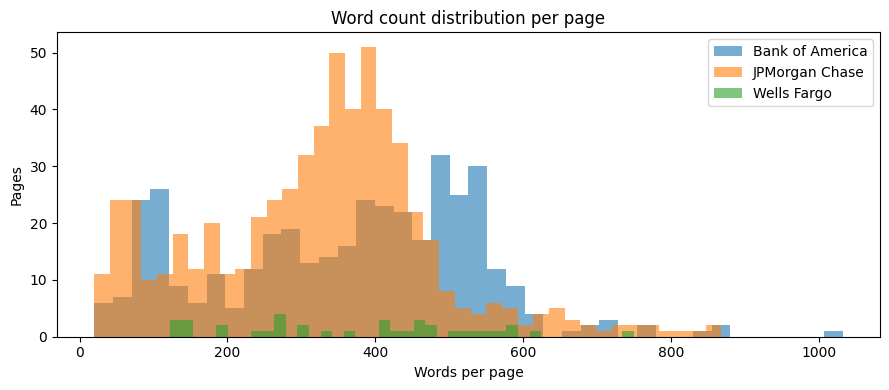

In [5]:
df_pages = pd.DataFrame(all_pages)

summary = df_pages.groupby('bank').agg(
    pages=('page', 'count'),
    total_words=('word_count', 'sum'),
    avg_words=('word_count', 'mean'),
).round(0)
print(summary.to_string())

fig, ax = plt.subplots(figsize=(9, 4))
for bank, grp in df_pages.groupby('bank'):
    ax.hist(grp['word_count'], bins=40, alpha=0.6, label=bank)
ax.set_xlabel('Words per page')
ax.set_ylabel('Pages')
ax.set_title('Word count distribution per page')
ax.legend()
plt.tight_layout()
plt.show()

In [6]:
sample = df_pages[df_pages['bank'] == 'JPMorgan Chase'].iloc[5]
print(f"Bank: {sample['bank']}  |  Page: {sample['page']}  |  Words: {sample['word_count']}")
print('---')
print(sample['text'][:500])

Bank: JPMorgan Chase  |  Page: 6  |  Words: 422
---
jpm-20231231 18/05/26, 1:12 p.m.
Segmentos de negocio
Para fines de informes de gestión, las actividades de
JPMorgan Chase se organizan en cuatro segmentos de
negocio principales que deben ser reportados, además de
un segmento Corporativo. El negocio de consumo de la
empresa es el segmento de Banca de Consumo y
Comunitaria (CCB). Los negocios mayoristas de la empresa
son los segmentos de Banca Corporativa y de Inversión
(CIB), Banca Comercial (CB) y Gestión de Activos y
Patrimonio (AWM).
En la s


## 6. Chunking

**chunk_size=500 words** — enough context per retrieval without excessive token cost.

**chunk_overlap=50 words** — ensures semantic continuity between adjacent chunks.

**Separators:** prefer paragraph → sentence → word boundaries.

In [7]:
chunks = chunk_documents(all_pages, chunk_size=500, chunk_overlap=50)
print(f'Total chunks generated: {len(chunks)}')

Total chunks generated: 1183


## 7. Chunk Quality Validation

Chunks per bank:
                 chunks
bank                   
Bank of America     485
JPMorgan Chase      652
Wells Fargo          46

Word count stats (all chunks):
count    1183.0
mean      303.1
std       147.4
min        31.0
25%       168.0
50%       331.0
75%       427.0
max       500.0
Name: word_count, dtype: float64


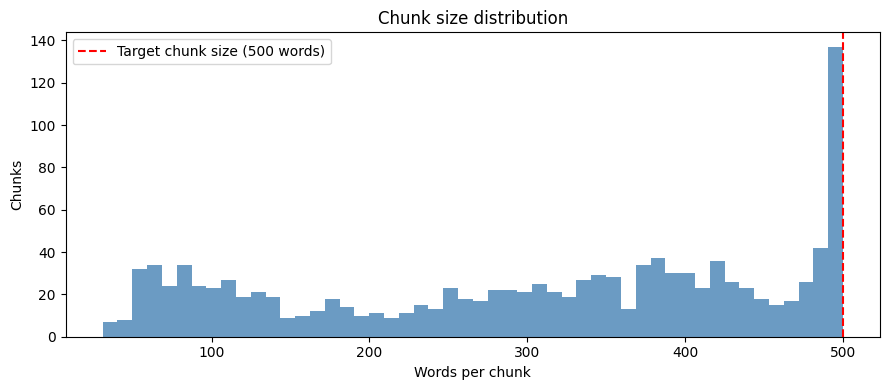

In [8]:
df_chunks = pd.DataFrame(chunks)

print('Chunks per bank:')
print(df_chunks.groupby('bank')[['chunk_id']].count().rename(columns={'chunk_id': 'chunks'}))

print('\nWord count stats (all chunks):')
print(df_chunks['word_count'].describe().round(1))

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(df_chunks['word_count'], bins=50, color='steelblue', alpha=0.8)
ax.axvline(500, color='red', linestyle='--', label='Target chunk size (500 words)')
ax.set_xlabel('Words per chunk')
ax.set_ylabel('Chunks')
ax.set_title('Chunk size distribution')
ax.legend()
plt.tight_layout()
plt.show()

In [9]:
sample_chunk = df_chunks[df_chunks['bank'] == 'JPMorgan Chase'].iloc[10]
print('chunk_id :', sample_chunk['chunk_id'])
print('bank     :', sample_chunk['bank'])
print('page     :', sample_chunk['page'])
print('words    :', sample_chunk['word_count'])
print('text     :', sample_chunk['text'][:300], '...')

chunk_id : JPM_2023_p0011_c000000
bank     : JPMorgan Chase
page     : 11
words    : 410
text     : jpm-20231231 18/05/26, 1:12 p.m.
Cultura empresarial
Los fundamentos de la cultura de JPMorgan Chase son su
propósito, valores y "Principios Empresariales". Estos
principios rectores, establecidos por la Firma, se
consideran esenciales para su éxito y se resumen en
cuatro pilares corporativos centra ...


## 8. Save Chunks to JSON

In [10]:
save_chunks(chunks, CHUNKS_PATH)

# Round-trip verification
loaded = load_chunks(CHUNKS_PATH)
assert len(loaded) == len(chunks), 'Round-trip mismatch!'
print('Round-trip verification passed ✅')
print(f'\nReady for notebook 02 → {CHUNKS_PATH}')

Saved 1183 chunks → /Users/nicolaszuleta95/code_nz/financial-rag-assistant/data/processed/chunks_processed.json
Loaded 1183 chunks from /Users/nicolaszuleta95/code_nz/financial-rag-assistant/data/processed/chunks_processed.json
Round-trip verification passed ✅

Ready for notebook 02 → /Users/nicolaszuleta95/code_nz/financial-rag-assistant/data/processed/chunks_processed.json
